RetailPulse 360

Notebook 07 — Exploratory Data Analysis

Goal: Notebooks 01-06 built the data. This notebook properly explores it — quantifying
the seasonality, regional, and category patterns we've only seen informally in the app
so far, and specifically surfacing what Phase 3's forecasting model will need to account
for (trend, seasonality strength, store-to-store variance). This is where we go from
"the data looks right" to "here's precisely how demand behaves."

Input: sales.csv, stores.csv, skus.csv, products.csv, inventory_turnover_summary.csv
Output: eda_summary.csv (key findings, for reference in later phases) + charts (inline)

In [7]:
# 1. IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


In [8]:
# 2. LOAD ALL DATA
# ============================================================

BASE_PATH = "/kaggle/input/datasets/hamaz911/notebook-7-dataset/"

stores = pd.read_csv(BASE_PATH + "stores.csv")
skus = pd.read_csv(BASE_PATH + "skus.csv")
products = pd.read_csv("/kaggle/input/datasets/hamaz911/product/products.csv")
sales = pd.read_csv(BASE_PATH + "sales.csv", parse_dates=["date"])
inventory_turnover = pd.read_csv(BASE_PATH + "inventory_turnover_summary.csv")

print("Loaded:")
for name, df in [("stores", stores), ("skus", skus), ("products", products),
                  ("sales", sales), ("inventory_turnover", inventory_turnover)]:
    print(f"  {name}: {df.shape}")

Loaded:
  stores: (191, 18)
  skus: (3296, 13)
  products: (72, 7)
  sales: (2459464, 4)
  inventory_turnover: (13678, 7)


In [9]:
# 3. DATA QUALITY — INTEGRATED CHECK ACROSS ALL FILES
# ============================================================
# Individual files were validated in their own notebooks. This checks
# they're still consistent NOW that we're combining all six together.

print("Missing values across all files:")
for name, df in [("stores", stores), ("skus", skus), ("products", products),
                  ("sales", sales), ("inventory_turnover", inventory_turnover)]:
    m = df.isna().sum()
    if m.sum() > 0:
        print(f"  {name}: {dict(m[m > 0])}")
print("(only the known STY-ECOM personality gap should show up here)")

print("\nReferential integrity:")
print("  sales -> stores orphans:", (~sales["store_id"].isin(stores["store_id"])).sum())
print("  sales -> skus orphans:", (~sales["sku_id"].isin(skus["sku_id"])).sum())
print("  skus -> products orphans:", (~skus["product_id"].isin(products["product_id"])).sum())
print("  inventory_turnover -> stores orphans:", (~inventory_turnover["store_id"].isin(stores["store_id"])).sum())
print("  inventory_turnover -> products orphans:", (~inventory_turnover["product_id"].isin(products["product_id"])).sum())

print("\nDate range check:", sales["date"].min(), "to", sales["date"].max())
print("Total days:", (sales["date"].max() - sales["date"].min()).days + 1)

Missing values across all files:
  stores: {'store_size': np.int64(1), 'rossmann_store_id': np.int64(1), 'dow_mon': np.int64(1), 'dow_tue': np.int64(1), 'dow_wed': np.int64(1), 'dow_thu': np.int64(1), 'dow_fri': np.int64(1), 'dow_sat': np.int64(1), 'dow_sun': np.int64(1), 'promo_lift': np.int64(1), 'trend_pct_per_year': np.int64(1), 'volatility_cv': np.int64(1), 'holiday_lift': np.int64(1)}
  inventory_turnover: {'active_daily_velocity': np.int64(9), 'days_of_supply': np.int64(9)}
(only the known STY-ECOM personality gap should show up here)

Referential integrity:
  sales -> stores orphans: 0
  sales -> skus orphans: 0
  skus -> products orphans: 0
  inventory_turnover -> stores orphans: 0
  inventory_turnover -> products orphans: 0

Date range check: 2024-02-23 00:00:00 to 2026-08-23 00:00:00
Total days: 913


Daily units — basic stats:
count     913.000000
mean     2741.386637
std       486.799673
min      1924.000000
25%      2396.000000
50%      2564.000000
75%      3099.000000
max      4583.000000
Name: units_sold, dtype: float64


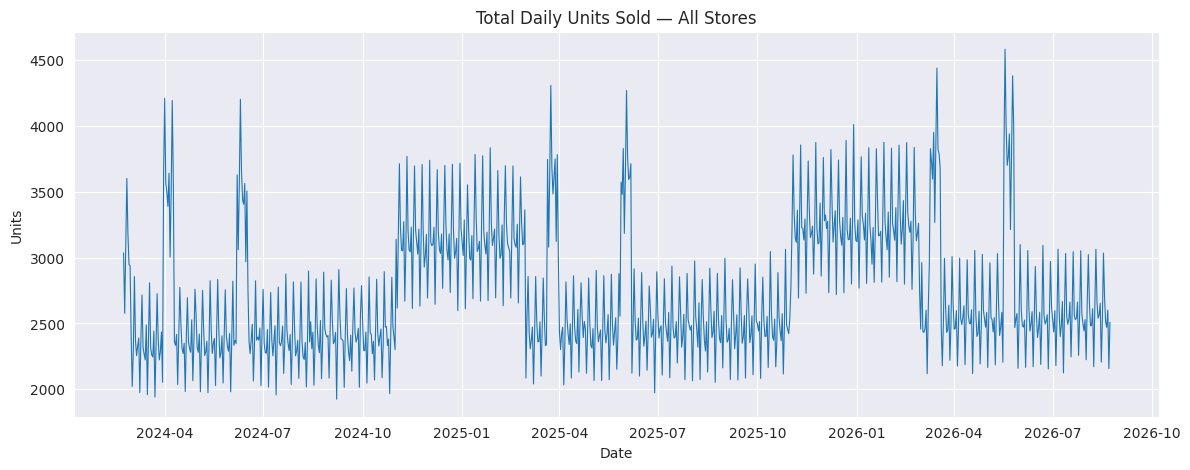

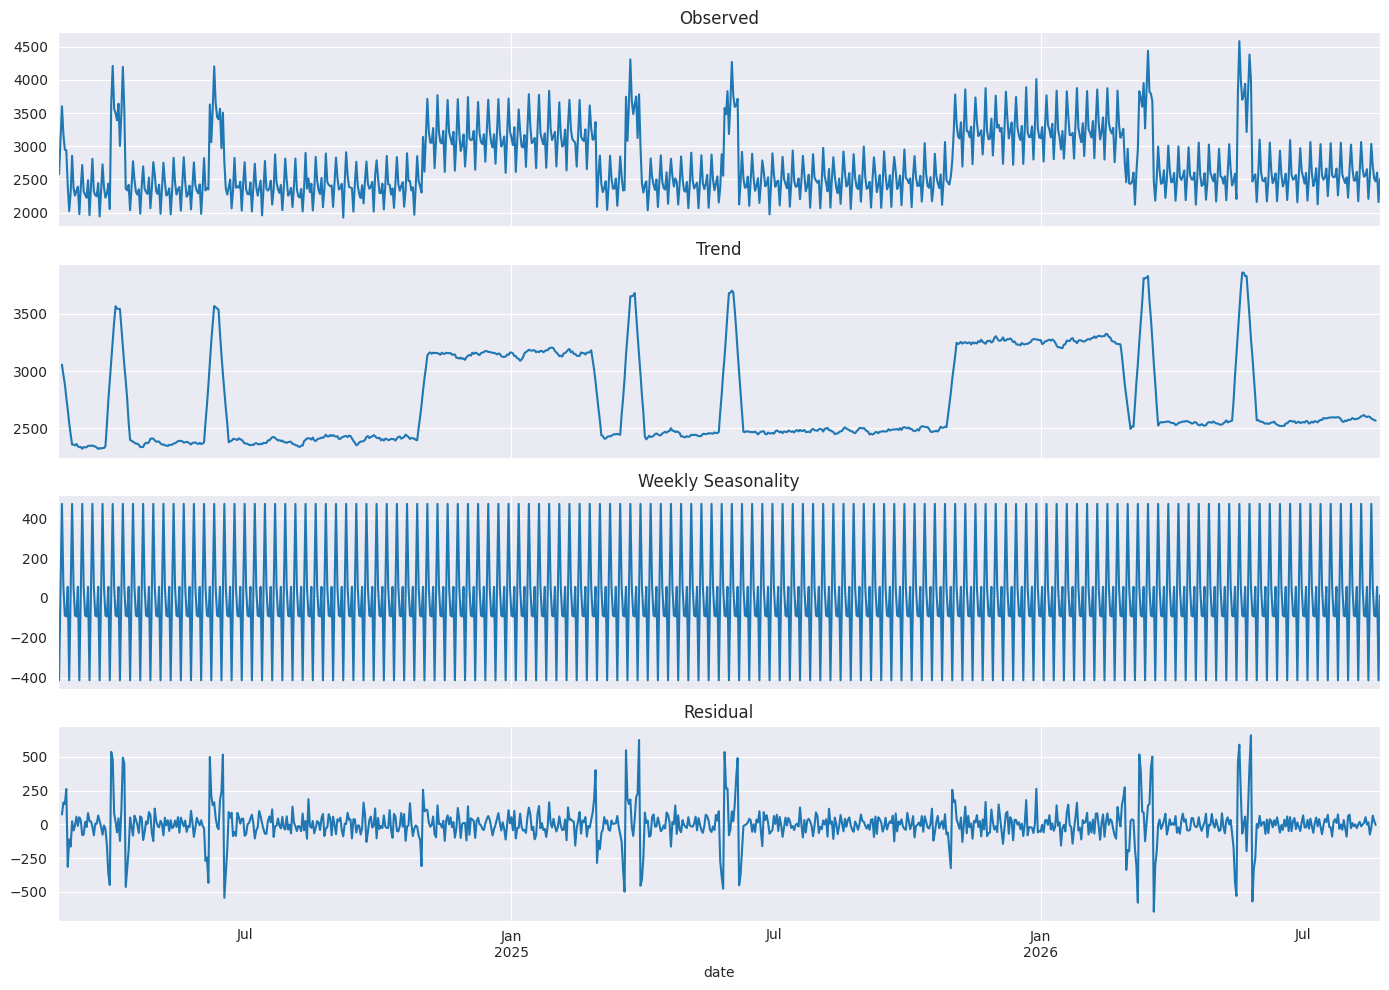

In [10]:
# 4. AGGREGATE DAILY SALES + TIME SERIES DECOMPOSITION
# ============================================================
from statsmodels.tsa.seasonal import seasonal_decompose

daily_units = sales.groupby("date")["units_sold"].sum()

print("Daily units — basic stats:")
print(daily_units.describe())

plt.figure(figsize=(14, 5))
plt.plot(daily_units.index, daily_units.values, linewidth=0.8)
plt.title("Total Daily Units Sold — All Stores")
plt.xlabel("Date")
plt.ylabel("Units")
plt.show()

# Decompose: period=7 captures weekly rhythm (the day-of-week ratios
# from Rossmann personalities, all the way back in Notebook 01)
decomposition = seasonal_decompose(daily_units, model="additive", period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title="Observed")
decomposition.trend.plot(ax=axes[1], title="Trend")
decomposition.seasonal.plot(ax=axes[2], title="Weekly Seasonality")
decomposition.resid.plot(ax=axes[3], title="Residual")
plt.tight_layout()
plt.show()

In [12]:
# 5. QUANTIFY SEASONALITY EFFECTS (REAL NUMBERS, NOT JUST VISUAL)
# ============================================================
EID_DATES = [
    "2024-04-10", "2024-06-17", "2025-03-31",
    "2025-06-07", "2026-03-20", "2026-05-27",
]
PRE_EID_WINDOW = 10

daily = daily_units.reset_index()
daily.columns = ["date", "units"]
daily["month"] = daily["date"].dt.month
daily["day_name"] = daily["date"].dt.day_name()

daily["is_pre_eid"] = False
for eid in EID_DATES:
    eid_ts = pd.Timestamp(eid)
    mask = (daily["date"] >= eid_ts - pd.Timedelta(days=PRE_EID_WINDOW)) & (daily["date"] < eid_ts)
    daily.loc[mask, "is_pre_eid"] = True

daily["is_wedding_season"] = daily["month"].isin([11, 12, 1, 2])

baseline = daily[~daily["is_pre_eid"] & ~daily["is_wedding_season"]]["units"].mean()
pre_eid_avg = daily[daily["is_pre_eid"]]["units"].mean()
wedding_avg = daily[daily["is_wedding_season"] & ~daily["is_pre_eid"]]["units"].mean()

print(f"Baseline avg daily units (normal days): {baseline:.0f}")
print(f"Pre-Eid avg daily units: {pre_eid_avg:.0f}  ({(pre_eid_avg/baseline-1)*100:+.1f}% vs baseline)")
print(f"Wedding-season avg daily units: {wedding_avg:.0f}  ({(wedding_avg/baseline-1)*100:+.1f}% vs baseline)")

print("\nAvg units by day of week:")
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
print(daily.groupby("day_name")["units"].mean().reindex(dow_order).round(0))

Baseline avg daily units (normal days): 2461
Pre-Eid avg daily units: 3687  (+49.8% vs baseline)
Wedding-season avg daily units: 3200  (+30.0% vs baseline)

Avg units by day of week:
day_name
Monday       3215.0
Tuesday      2796.0
Wednesday    2653.0
Thursday     2648.0
Friday       2798.0
Saturday     2328.0
Sunday       2755.0
Name: units, dtype: float64


In [13]:
# 6. STORE-LEVEL VARIANCE + CATEGORY/GENDER PATTERNS
# ============================================================
sales_j = sales.merge(skus[["sku_id","category","gender"]], on="sku_id", how="left")
sales_j = sales_j.merge(stores[["store_id","store_size","region"]], on="store_id", how="left")

print("Units sold by category:")
print(sales_j.groupby("category")["units_sold"].sum().sort_values(ascending=False))

print("\nUnits sold by gender:")
print(sales_j.groupby("gender")["units_sold"].sum().sort_values(ascending=False))

store_totals = sales_j.groupby("store_id")["units_sold"].sum().reset_index()
store_totals = store_totals.merge(stores[["store_id","store_size"]], on="store_id", how="left")
print("\nAvg total units per store, by size (coefficient of variation shows spread):")
print(store_totals.groupby("store_size")["units_sold"].agg(["mean","std"]))
print("\nCV (std/mean) within each size tier:")
cv_by_size = store_totals.groupby("store_size")["units_sold"].agg(lambda x: x.std()/x.mean())
print(cv_by_size)

Units sold by category:
category
Formal    864031
Casual    821907
Sports    816948
Name: units_sold, dtype: int64

Units sold by gender:
gender
Kids       1393900
Women's     582016
Men's       526970
Name: units_sold, dtype: int64

Avg total units per store, by size (coefficient of variation shows spread):
                    mean          std
store_size                           
Large       23683.621622  1626.416090
Medium      18350.630769  1530.326921
Small        4929.556818   395.334977

CV (std/mean) within each size tier:
store_size
Large     0.068673
Medium    0.083394
Small     0.080197
Name: units_sold, dtype: float64


In [14]:
# 6b. FIX THE MISLEADING COMPARISON — NORMALIZE BY SKU COUNT
# ============================================================
# Raw totals scale with how finely a category happens to be sliced
# into SKUs (Kids has 19 sizes vs 8 for adults), not genuine demand
# intensity. Reporting per-SKU average alongside the raw total prevents
# this from being misread as a real business signal.

sku_counts_by_gender = skus.groupby("gender").size()
totals_by_gender = sales_j.groupby("gender")["units_sold"].sum()

comparison = pd.DataFrame({
    "total_units": totals_by_gender,
    "sku_count": sku_counts_by_gender,
})
comparison["avg_units_per_sku"] = comparison["total_units"] / comparison["sku_count"]

print("Gender comparison — raw total vs. per-SKU normalized:")
print(comparison.sort_values("avg_units_per_sku", ascending=False))
print("\nNote: total_units is inflated for Kids purely because it has more")
print("SKUs (19 sizes vs 8) — avg_units_per_sku is the fair comparison.")

Gender comparison — raw total vs. per-SKU normalized:
         total_units  sku_count  avg_units_per_sku
gender                                            
Kids         1393900       1824         764.199561
Women's       582016        768         757.833333
Men's         526970        704         748.536932

Note: total_units is inflated for Kids purely because it has more
SKUs (19 sizes vs 8) — avg_units_per_sku is the fair comparison.


In [15]:
# 7. INVENTORY HEALTH OVERVIEW
# ============================================================
print("Stock status distribution:")
print(inventory_turnover["stock_status"].value_counts())
print("\nAvg days of supply by store size:")
inv_with_size = inventory_turnover.merge(stores[["store_id","store_size"]], on="store_id", how="left")
active_inv = inv_with_size[inv_with_size["active_daily_velocity"] > 0]
print(active_inv.groupby("store_size")["days_of_supply"].mean().round(1))

print("\nTotal dead stock units across the network:", inventory_turnover["dead_stock_units"].sum())

Stock status distribution:
stock_status
Healthy               5153
Low                   4890
Critical (Reorder)    3469
Overstock              157
Fully Dead               9
Name: count, dtype: int64

Avg days of supply by store size:
store_size
Large     26.4
Medium    19.9
Small     13.0
Name: days_of_supply, dtype: float64

Total dead stock units across the network: 139146.0


In [16]:
# 8. SAVE EDA SUMMARY
# ============================================================
findings = pd.DataFrame([
    {"metric": "avg_daily_units_baseline", "value": round(baseline, 0)},
    {"metric": "pre_eid_uplift_pct", "value": round((pre_eid_avg/baseline-1)*100, 1)},
    {"metric": "wedding_season_uplift_pct", "value": round((wedding_avg/baseline-1)*100, 1)},
    {"metric": "store_variance_cv_large", "value": round(cv_by_size["Large"], 4)},
    {"metric": "store_variance_cv_medium", "value": round(cv_by_size["Medium"], 4)},
    {"metric": "store_variance_cv_small", "value": round(cv_by_size["Small"], 4)},
    {"metric": "avg_units_per_sku_kids", "value": round(comparison.loc["Kids","avg_units_per_sku"], 1)},
    {"metric": "avg_units_per_sku_mens", "value": round(comparison.loc["Men's","avg_units_per_sku"], 1)},
    {"metric": "avg_units_per_sku_womens", "value": round(comparison.loc["Women's","avg_units_per_sku"], 1)},
])
findings.to_csv("eda_summary.csv", index=False)
print("Saved eda_summary.csv")
print(findings)

print("\n✓ Notebook 07 completed successfully.")

Saved eda_summary.csv
                      metric      value
0   avg_daily_units_baseline  2461.0000
1         pre_eid_uplift_pct    49.8000
2  wedding_season_uplift_pct    30.0000
3    store_variance_cv_large     0.0687
4   store_variance_cv_medium     0.0834
5    store_variance_cv_small     0.0802
6     avg_units_per_sku_kids   764.2000
7     avg_units_per_sku_mens   748.5000
8   avg_units_per_sku_womens   757.8000

✓ Notebook 07 completed successfully.
